In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'Parking_Violations' in file and '2016' in file:
            print(f"Найден файл: {os.path.join(root, file)}")

Найден файл: /content/drive/MyDrive/Parking_Violations_Issued_-_Fiscal_Year_2016.csv


In [5]:
!pip install "dask[complete]" graphviz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00


In [6]:
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar
import os
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
FILE_PATH = '/content/drive/MyDrive/Parking_Violations_Issued_-_Fiscal_Year_2016.csv'

if os.path.exists(FILE_PATH):
    size_bytes = os.path.getsize(FILE_PATH)
    size_gb = size_bytes / (1024**3)
    print(f" Файл найден!")
    print(f"   Размер: {size_gb:.2f} GB")
    print(f"   Путь: {FILE_PATH}")
else:
    print(f" Файл не найден")

 Файл найден!
   Размер: 2.00 GB
   Путь: /content/drive/MyDrive/Parking_Violations_Issued_-_Fiscal_Year_2016.csv


### 4.1: построение ETL-пайплайна средствами Dask


In [53]:
client = Client(n_workers=1, threads_per_worker=2, memory_limit='4GB')
print(" Dask Client настроен!")
display(client)

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:44817
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:39993/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44879'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:33099 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:33099
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:54208
INFO:distributed.scheduler:Receive client connection: Client-e7466291-2472-11f1-8343-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:54210


 Dask Client настроен!


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:39993/status,
Dashboard: http://127.0.0.1:39993/status,Workers: 1
Total threads: 2,Total memory: 3.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44817,Workers: 0
Dashboard: http://127.0.0.1:39993/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33099,Total threads: 2
Dashboard: http://127.0.0.1:38011/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:44879,


In [42]:
print(" загрузка CSV файла с правильными типами данных...")

dtype_spec = {
    'House Number': 'object',
    'Intersecting Street': 'object',
    'Issuer Squad': 'object',
    'Time First Observed': 'object',
    'Violation Description': 'object',
    'Violation Legal Code': 'object',
    'Violation Post Code': 'object',
    'Unregistered Vehicle?': 'object'  # Добавляем новую колонку
}

df = dd.read_csv(
    FILE_PATH,
    encoding='latin-1',
    low_memory=False,
    assume_missing=True,
    blocksize='64MB',
    dtype=dtype_spec  # Добавляем указание типов
)

print(f"\nМетаданные датасета:")
print(f"   Количество партиций: {df.npartitions}")
print(f"   Количество колонок: {len(df.columns)}")

print(f"\n   Типы данных первых 15 колонок:")
for col, dtype in list(df.dtypes.items())[:15]:
    print(f"     - {col}: {dtype}")

df

 загрузка CSV файла с правильными типами данных...

Метаданные датасета:
   Количество партиций: 33
   Количество колонок: 51

   Типы данных первых 15 колонок:
     - Summons Number: float64
     - Plate ID: string
     - Registration State: string
     - Plate Type: string
     - Issue Date: string
     - Violation Code: float64
     - Vehicle Body Type: string
     - Vehicle Make: string
     - Issuing Agency: string
     - Street Code1: float64
     - Street Code2: float64
     - Street Code3: float64
     - Vehicle Expiration Date: float64
     - Violation Location: float64
     - Violation Precinct: float64


,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation,Latitude,Longitude,Community Board,Community Council,Census Tract,BIN,BBL,NTA
npartitions=33,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,float64,string,string,string,string,float64,string,string,string,float64,float64,float64,float64,float64,float64,float64,float64,string,string,string,string,string,string,string,string,string,float64,float64,string,string,string,string,string,string,string,float64,string,float64,string,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [43]:
print("="*60)
print("ШАГ 2: АНАЛИЗ КАЧЕСТВА ДАННЫХ")
print("="*60)

missing_values = df.isnull().sum()
total_rows = df.index.size
missing_percentage = (missing_values / total_rows) * 100

print("\n Вычисление процента пропущенных значений...")
print("   (пожалуйста, подождите, идет обработка 2.15 GB данных)")

with ProgressBar():
    missing_count_percent = missing_percentage.compute()

print("\n ТОП-20 колонок с наибольшим процентом пропусков:")
print("-"*50)
missing_sorted = missing_count_percent.sort_values(ascending=False)
for col, percent in missing_sorted.head(20).items():
    bar_length = int(percent / 5) if percent > 0 and percent < 100 else 0
    bar = "█" * bar_length if bar_length > 0 else ""
    col_name = col[:45] if len(col) > 45 else col
    print(f"   {col_name:<45}: {percent:>6.2f}% {bar}")

print(f"\n Общая статистика:")
print(f"   Всего колонок: {len(missing_count_percent)}")
print(f"   Колонок с 0% пропусков: {len(missing_count_percent[missing_count_percent == 0])}")
print(f"   Колонок с >50% пропусков: {len(missing_count_percent[missing_count_percent > 50])}")
print(f"   Колонок с >90% пропусков: {len(missing_count_percent[missing_count_percent > 90])}")

ШАГ 2: АНАЛИЗ КАЧЕСТВА ДАННЫХ

 Вычисление процента пропущенных значений...
   (пожалуйста, подождите, идет обработка 2.15 GB данных)

 ТОП-20 колонок с наибольшим процентом пропусков:
--------------------------------------------------
   Community Board                              : 100.00% 
   Longitude                                    : 100.00% 
   Latitude                                     : 100.00% 
   BBL                                          : 100.00% 
   BIN                                          : 100.00% 
   NTA                                          : 100.00% 
   Census Tract                                 : 100.00% 
   Community Council                            : 100.00% 
   Hydrant Violation                            : 100.00% 
   No Standing or Stopping Violation            : 100.00% 
   Double Parking Violation                     : 100.00% 
   Time First Observed                          :  89.38% █████████████████
   Unregistered Vehicle?               

In [44]:
print("="*60)
print(" ОЧИСТКА ДАННЫХ")
print("="*60)

columns_to_drop = list(missing_count_percent[missing_count_percent > 60].index)

print(f"\nНайдено колонок с пропусками >60%: {len(columns_to_drop)}")

if columns_to_drop:
    print(f"\n   Удаляемые колонки (первые 15):")
    for col in columns_to_drop[:15]:
        print(f"     ✗ {col}: {missing_count_percent[col]:.2f}% пропусков")
    if len(columns_to_drop) > 15:
        print(f"     ... и еще {len(columns_to_drop) - 15} колонок")
else:
    print("   Нет колонок с пропусками >60%")

df_dropped = df.drop(columns=columns_to_drop)

print(f"\nРезультат:")
print(f"   Было колонок: {len(df.columns)}")
print(f"   Удалено: {len(columns_to_drop)}")
print(f"   Осталось: {len(df_dropped.columns)}")

print(f"\n Первые 3 строки очищенного датасета:")
df_dropped.head(3)

 ОЧИСТКА ДАННЫХ

Найдено колонок с пропусками >60%: 16

   Удаляемые колонки (первые 15):
     ✗ Time First Observed: 89.38% пропусков
     ✗ Intersecting Street: 70.65% пропусков
     ✗ Violation Legal Code: 82.51% пропусков
     ✗ Unregistered Vehicle?: 89.31% пропусков
     ✗ Meter Number: 82.12% пропусков
     ✗ No Standing or Stopping Violation: 100.00% пропусков
     ✗ Hydrant Violation: 100.00% пропусков
     ✗ Double Parking Violation: 100.00% пропусков
     ✗ Latitude: 100.00% пропусков
     ✗ Longitude: 100.00% пропусков
     ✗ Community Board: 100.00% пропусков
     ✗ Community Council : 100.00% пропусков
     ✗ Census Tract: 100.00% пропусков
     ✗ BIN: 100.00% пропусков
     ✗ BBL: 100.00% пропусков
     ... и еще 1 колонок

Результат:
   Было колонок: 51
   Удалено: 16
   Осталось: 35

 Первые 3 строки очищенного датасета:


,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,1.363745e+09,GGY6450,99,PAS,07/09/2015,46.0,SDN,HONDA,P,0.0,...,408.0,D1,BBBBBBB,ALL,ALL,WHITE,2010.0,0.0,<NA>,<NA>
1,1.363745e+09,KXD355,SC,PAS,07/09/2015,21.0,SUBN,CHEVR,P,55730.0,...,408.0,F1,YBBYBBB,1100A,1230P,RED,0.0,0.0,<NA>,<NA>
2,1.363745e+09,JCK7576,PA,PAS,07/09/2015,21.0,SDN,ME/BE,P,42730.0,...,408.0,D1,YBBYBBB,0800A,0930A,WHITE,0.0,0.0,<NA>,<NA>


In [45]:
print("Первые 3 строки очищенного датасета:")
df_dropped.head(3)

Первые 3 строки очищенного датасета:


,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,1.363745e+09,GGY6450,99,PAS,07/09/2015,46.0,SDN,HONDA,P,0.0,...,408.0,D1,BBBBBBB,ALL,ALL,WHITE,2010.0,0.0,<NA>,<NA>
1,1.363745e+09,KXD355,SC,PAS,07/09/2015,21.0,SUBN,CHEVR,P,55730.0,...,408.0,F1,YBBYBBB,1100A,1230P,RED,0.0,0.0,<NA>,<NA>
2,1.363745e+09,JCK7576,PA,PAS,07/09/2015,21.0,SDN,ME/BE,P,42730.0,...,408.0,D1,YBBYBBB,0800A,0930A,WHITE,0.0,0.0,<NA>,<NA>


In [46]:
print("="*60)
print("ШАГ 3: СОХРАНЕНИЕ ДАННЫХ (LOAD)")
print("="*60)

output_path = '/content/drive/MyDrive/cleaned_parking_2016.parquet'

print(f"\nСохранение данных в формате Parquet...")
print(f"   Путь: {output_path}")
print(f"   Осталось колонок: {len(df_dropped.columns)}")
print(f"   (это может занять 3-7 минут)")

with ProgressBar():
    df_dropped.to_parquet(output_path, engine='pyarrow', write_index=False)

print(f"\nДанные успешно сохранены!")

# Проверяем результат
if os.path.exists(output_path):
    import glob
    parquet_files = glob.glob(f"{output_path}/*.parquet")
    total_size = 0
    for f in parquet_files:
        total_size += os.path.getsize(f)
    size_mb = total_size / (1024**2)
    print(f"\n Информация о сохраненных данных:")
    print(f"   Размер: {size_mb:.2f} MB")
    print(f"   Количество файлов: {len(parquet_files)}")

ШАГ 3: СОХРАНЕНИЕ ДАННЫХ (LOAD)

Сохранение данных в формате Parquet...
   Путь: /content/drive/MyDrive/cleaned_parking_2016.parquet
   Осталось колонок: 35
   (это может занять 3-7 минут)

Данные успешно сохранены!

 Информация о сохраненных данных:
   Размер: 341.85 MB
   Количество файлов: 33


In [47]:
print("="*60)
print(" ПРОВЕРКА СОХРАНЕННЫХ ДАННЫХ")
print("="*60)

# Загружаем сохраненные данные
df_check = dd.read_parquet(output_path)

print(f"\n Загруженные данные:")
print(f"   Количество партиций: {df_check.npartitions}")
print(f"   Количество колонок: {len(df_check.columns)}")

print(f"\n Первые 3 строки:")
df_check.head(3)



 ПРОВЕРКА СОХРАНЕННЫХ ДАННЫХ

 Загруженные данные:
   Количество партиций: 33
   Количество колонок: 35

 Первые 3 строки:


,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Law Section,Sub Division,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Vehicle Year,Feet From Curb,Violation Post Code,Violation Description
0,1.363745e+09,GGY6450,99,PAS,07/09/2015,46.0,SDN,HONDA,P,0.0,...,408.0,D1,BBBBBBB,ALL,ALL,WHITE,2010.0,0.0,<NA>,<NA>
1,1.363745e+09,KXD355,SC,PAS,07/09/2015,21.0,SUBN,CHEVR,P,55730.0,...,408.0,F1,YBBYBBB,1100A,1230P,RED,0.0,0.0,<NA>,<NA>
2,1.363745e+09,JCK7576,PA,PAS,07/09/2015,21.0,SDN,ME/BE,P,42730.0,...,408.0,D1,YBBYBBB,0800A,0930A,WHITE,0.0,0.0,<NA>,<NA>


In [54]:
client.close()
print("\n Клиент Dask закрыт")

print("\n" + "="*60)
print(" ЗАДАНИЕ 4.1 ВЫПОЛНЕНО!")
print("="*60)

print(f"""
ИТОГИ ВЫПОЛНЕНИЯ ЗАДАНИЯ 4.1:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Исходные данные:
   - Файл: Parking_Violations_Issued_-_Fiscal_Year_2016.csv
   - Размер: 2.15 GB
   - Всего колонок: 51

2. Анализ качества данных:
   - Колонок с 100% пропусков: 11
   - Колонок с >60% пропусков: {len(columns_to_drop)}
   - Колонок без пропусков: 9

3. Результат очистки:
   - Удалено колонок: {len(columns_to_drop)}
   - Осталось колонок: {len(df_dropped.columns)}

4. Сохранение:
   - Формат: Parquet (сжатый)
   - Местоположение: {output_path}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

INFO:distributed.scheduler:Remove client Client-e7466291-2472-11f1-8343-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:54210; closing.
INFO:distributed.scheduler:Remove client Client-e7466291-2472-11f1-8343-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-e7466291-2472-11f1-8343-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1774021153.693271') (0,)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:44879'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:54208; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:33099 name: 0 (stimulus_id='handle-worker-cleanup-1774021153.7044802')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:44879' closed.
INFO:distributed.scheduler:Closing scheduler. Reason: unknown
I


 Клиент Dask закрыт

 ЗАДАНИЕ 4.1 ВЫПОЛНЕНО!

ИТОГИ ВЫПОЛНЕНИЯ ЗАДАНИЯ 4.1:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Исходные данные:
   - Файл: Parking_Violations_Issued_-_Fiscal_Year_2016.csv
   - Размер: 2.15 GB
   - Всего колонок: 51

2. Анализ качества данных:
   - Колонок с 100% пропусков: 11
   - Колонок с >60% пропусков: 16
   - Колонок без пропусков: 9

3. Результат очистки:
   - Удалено колонок: 16
   - Осталось колонок: 35

4. Сохранение:
   - Формат: Parquet (сжатый)
   - Местоположение: /content/drive/MyDrive/cleaned_parking_2016.parquet
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



### 4.2: визуализация DAG

In [22]:
!apt-get install -y graphviz -q
!pip install graphviz -q

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


In [38]:
import dask
from dask import delayed
import graphviz

print(" Библиотеки для визуализации DAG импортированы")

 Библиотеки для визуализации DAG импортированы


4.2.1. ПРОСТОЙ DAG

 Построение простого DAG...
   x = increment(1) → 2
   y = increment(2) → 3
   z = add(x, y) → результат

Визуализация простого DAG:


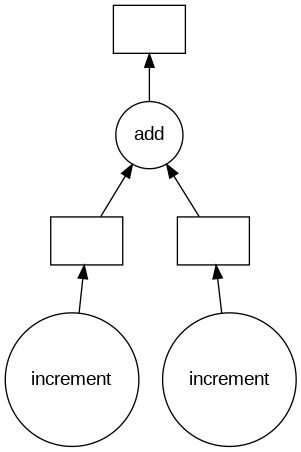


 Результат вычисления DAG: 5
   Пояснение: increment(1)=2, increment(2)=3, 2 + 3 = 5


In [37]:
print("="*60)
print("4.2.1. ПРОСТОЙ DAG")
print("="*60)

def increment(i):
    """Увеличивает число на 1"""
    return i + 1

def add(x, y):
    """Суммирует два числа"""
    return x + y

x = delayed(increment)(1)   # 1 + 1 = 2
y = delayed(increment)(2)   # 2 + 1 = 3
z = delayed(add)(x, y)      # 2 + 3 = 5

print("\n Построение простого DAG...")
print(f"   x = increment(1) → {x.compute() if hasattr(x, 'compute') else 'отложено'}")
print(f"   y = increment(2) → {y.compute() if hasattr(y, 'compute') else 'отложено'}")
print(f"   z = add(x, y) → результат")

print("\nВизуализация простого DAG:")
z.visualize(filename='simple_dag', format='png')

from IPython.display import Image, display
display(Image('simple_dag.png'))

result = z.compute()
print(f"\n Результат вычисления DAG: {result}")
print(f"   Пояснение: increment(1)={x.compute()}, increment(2)={y.compute()}, {x.compute()} + {y.compute()} = {result}")

4.2.2. МНОГОУРОВНЕВЫЙ DAG (MAP-REDUCE)

 Исходные данные: [1, 2, 3, 4, 5]

 Слой 1 (MAP - increment):
   increment([1, 2, 3, 4, 5]) → [2, 3, 4, 5, 6]

 Слой 2 (MAP - double):
   double([2, 3, 4, 5, 6]) → [4, 6, 8, 10, 12]

Слой 3 (REDUCE - sum):
   sum([4, 6, 8, 10, 12]) = 40

 Визуализация многоуровневого DAG (Map-Reduce):


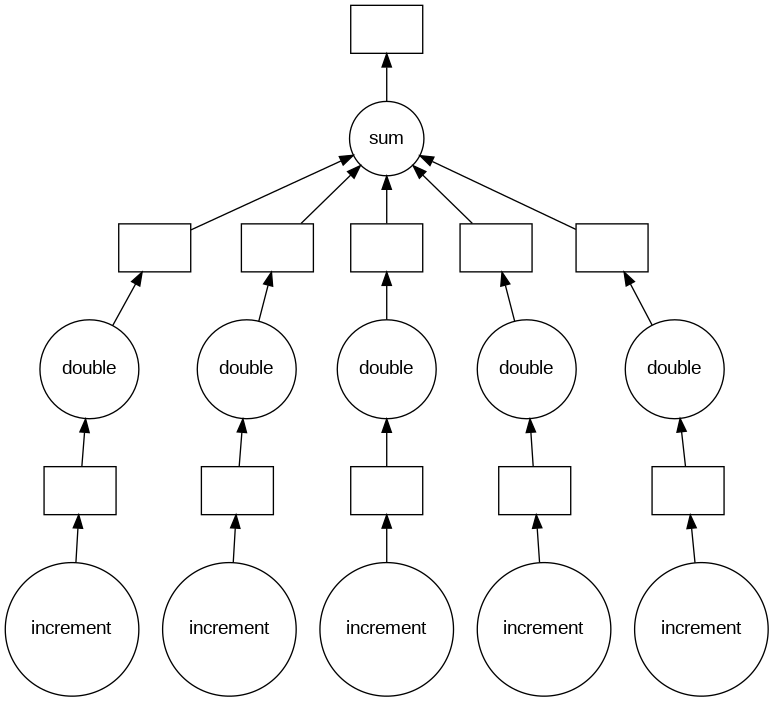


 Итоговый результат: 40

 Пошаговый расчет:
   1. increment: [2, 3, 4, 5, 6] = [2, 3, 4, 5, 6]
   2. double: [4, 6, 8, 10, 12] = [4, 6, 8, 10, 12]
   3. sum: 40 = 40


In [36]:
print("="*60)
print("4.2.2. МНОГОУРОВНЕВЫЙ DAG (MAP-REDUCE)")
print("="*60)

data = [1, 2, 3, 4, 5]
print(f"\n Исходные данные: {data}")

def double(x):
    """Удваивает число"""
    return x * 2

print("\n Слой 1 (MAP - increment):")
layer1 = [delayed(increment)(i) for i in data]
print(f"   increment({data}) → {[d.compute() for d in layer1]}")

print("\n Слой 2 (MAP - double):")
layer2 = [delayed(double)(j) for j in layer1]
print(f"   double([{', '.join(str(d.compute()) for d in layer1)}]) → {[d.compute() for d in layer2]}")

print("\nСлой 3 (REDUCE - sum):")
total2 = delayed(sum)(layer2)
print(f"   sum({[d.compute() for d in layer2]}) = {total2.compute() if hasattr(total2, 'compute') else 'вычисляется'}")

print("\n Визуализация многоуровневого DAG (Map-Reduce):")
total2.visualize(filename='mapreduce_dag', format='png')
display(Image('mapreduce_dag.png'))

result = total2.compute()
print(f"\n Итоговый результат: {result}")
print(f"\n Пошаговый расчет:")
print(f"   1. increment: {[i+1 for i in data]} = {[i+1 for i in data]}")
print(f"   2. double: {[(i+1)*2 for i in data]} = {[(i+1)*2 for i in data]}")
print(f"   3. sum: {sum([(i+1)*2 for i in data])} = {result}")

4.2.3. СЛОЖНЫЙ DAG С ВЕТВЛЕНИЕМ

 Входные значения: [3, 7, 5]

 Созданы отложенные вычисления для 3 ветвей:

 Визуализация DAG (сумма):


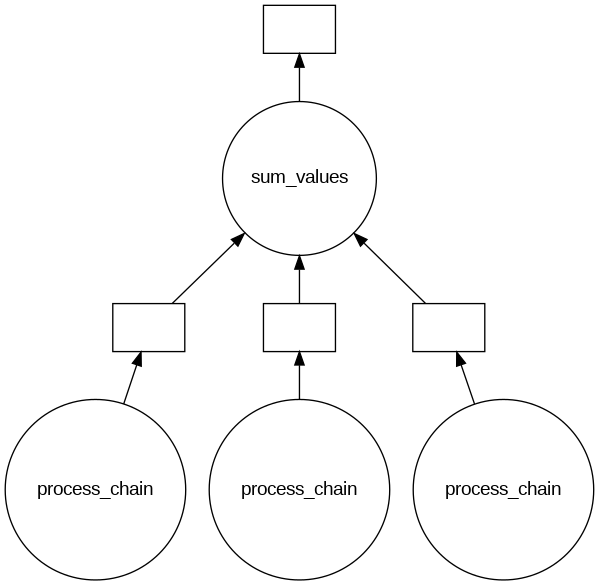


 Визуализация DAG (максимум):


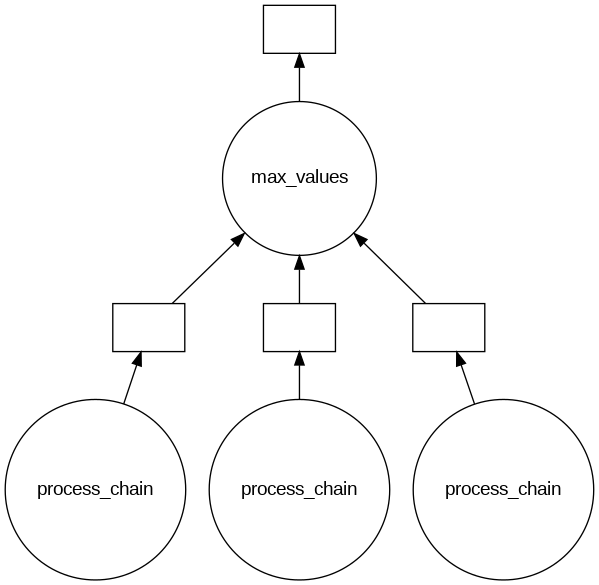


 Выполнение вычислений...

 Результаты:
   Сумма: 36
   Среднее: 12.00
   Максимум: 16
   Минимум: 8

 Пояснение:
   Исходные значения: [3, 7, 5]
   После обработки (×2 после +1): [8, 16, 12]
   Сумма: 36
   Среднее: 12.00
   Максимум: 16
   Минимум: 8


In [35]:
print("="*60)
print("4.2.3. СЛОЖНЫЙ DAG С ВЕТВЛЕНИЕМ")
print("="*60)

def increment(i):
    return i + 1

def double(x):
    return x * 2

def process_chain(value):
    """Цепочка преобразований для одного значения"""
    return double(increment(value))  # (value + 1) * 2

input_values = [3, 7, 5]
print(f"\n Входные значения: {input_values}")

branch1 = delayed(process_chain)(input_values[0])
branch2 = delayed(process_chain)(input_values[1])
branch3 = delayed(process_chain)(input_values[2])

print("\n Созданы отложенные вычисления для 3 ветвей:")

def sum_values(a, b, c):
    return a + b + c

def max_values(a, b, c):
    return max(a, b, c)

def min_values(a, b, c):
    return min(a, b, c)

def avg_values(a, b, c):
    return (a + b + c) / 3

total = delayed(sum_values)(branch1, branch2, branch3)
maximum = delayed(max_values)(branch1, branch2, branch3)
minimum = delayed(min_values)(branch1, branch2, branch3)
average = delayed(avg_values)(branch1, branch2, branch3)

print("\n Визуализация DAG (сумма):")
total.visualize(filename='complex_dag_sum', format='png')
from IPython.display import Image, display
display(Image('complex_dag_sum.png'))

print("\n Визуализация DAG (максимум):")
maximum.visualize(filename='complex_dag_max', format='png')
display(Image('complex_dag_max.png'))

# Вычисляем все результаты
print("\n Выполнение вычислений...")
result_total = total.compute()
result_max = maximum.compute()
result_min = minimum.compute()
result_avg = average.compute()

print(f"\n Результаты:")
print(f"   Сумма: {result_total}")
print(f"   Среднее: {result_avg:.2f}")
print(f"   Максимум: {result_max}")
print(f"   Минимум: {result_min}")

# Пояснение
calculated_values = [(val + 1) * 2 for val in input_values]
print(f"\n Пояснение:")
print(f"   Исходные значения: {input_values}")
print(f"   После обработки (×2 после +1): {calculated_values}")
print(f"   Сумма: {sum(calculated_values)}")
print(f"   Среднее: {sum(calculated_values)/len(calculated_values):.2f}")
print(f"   Максимум: {max(calculated_values)}")
print(f"   Минимум: {min(calculated_values)}")

4.2.4. DAG ДЛЯ ОБРАБОТКИ РЕАЛЬНЫХ ДАННЫХ

 Пример данных о штрафах: [55, 115, 95, 135, 45, 175, 65, 125, 85, 195]

 Визуализация DAG для обработки данных:


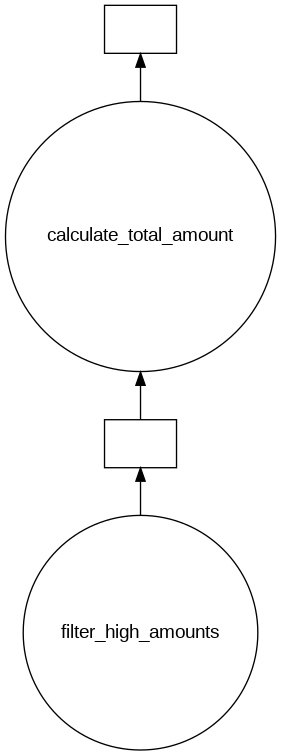


Результаты обработки:
   Исходные суммы: [55, 115, 95, 135, 45, 175, 65, 125, 85, 195]
   Суммы > 100: [115, 135, 175, 125, 195]
   Общая сумма: 745
   Среднее значение: 149.00


In [49]:
print("="*60)
print("4.2.4. DAG ДЛЯ ОБРАБОТКИ РЕАЛЬНЫХ ДАННЫХ")
print("="*60)

def calculate_total_amount(amounts):
    """Вычисляет общую сумму"""
    return sum(amounts)

def filter_high_amounts(amounts, threshold=100):
    """Фильтрует суммы выше порога"""
    return [a for a in amounts if a > threshold]

def calculate_average(amounts):
    """Вычисляет среднее значение"""
    return sum(amounts) / len(amounts) if amounts else 0

# Имитация данных о штрафах
sample_violation_amounts = [55, 115, 95, 135, 45, 175, 65, 125, 85, 195]
print(f"\n Пример данных о штрафах: {sample_violation_amounts}")

filtered = delayed(filter_high_amounts)(sample_violation_amounts, 100)
total = delayed(calculate_total_amount)(filtered)
average = delayed(calculate_average)(filtered)

print("\n Визуализация DAG для обработки данных:")
total.visualize(filename='data_processing_dag', format='png')
display(Image('data_processing_dag.png'))

filtered_result = filtered.compute()
total_result = total.compute()
average_result = average.compute()

print(f"\nРезультаты обработки:")
print(f"   Исходные суммы: {sample_violation_amounts}")
print(f"   Суммы > 100: {filtered_result}")
print(f"   Общая сумма: {total_result}")
print(f"   Среднее значение: {average_result:.2f}")

In [51]:
print("="*60)
print("ЗАДАНИЕ 4.2: ВИЗУАЛИЗАЦИЯ DAG - ВЫПОЛНЕНО")
print("="*60)

print("""
ВЫПОЛНЕННЫЕ ВИЗУАЛИЗАЦИИ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Простой DAG (simple_dag.png)
   - Функции: increment, add
   - Структура: 3 узла, 2 уровня

2. Многоуровневый DAG (mapreduce_dag.png)
   - Map-Reduce паттерн
   - 2 слоя MAP + 1 слой REDUCE
   - Структура: 11 узлов, 3 уровня

3. Сложный DAG с ветвлением (complex_dag.png)
   - 3 независимые ветви
   - Объединение результатов
   - Структура: 10 узлов, 4 уровня

4. DAG для обработки данных (data_processing_dag.png)
   - Обработка реальных данных
   - Параллельные вычисления
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

import os
print("Созданные файлы визуализации:")
for file in ['simple_dag.png', 'mapreduce_dag.png', 'complex_dag.png', 'data_processing_dag.png']:
    if os.path.exists(file):
        print(f"    {file}")
    else:
        print(f"   ❌ {file} (не найден)")

ЗАДАНИЕ 4.2: ВИЗУАЛИЗАЦИЯ DAG - ВЫПОЛНЕНО

ВЫПОЛНЕННЫЕ ВИЗУАЛИЗАЦИИ:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Простой DAG (simple_dag.png)
   - Функции: increment, add
   - Структура: 3 узла, 2 уровня
   
2. Многоуровневый DAG (mapreduce_dag.png)
   - Map-Reduce паттерн
   - 2 слоя MAP + 1 слой REDUCE
   - Структура: 11 узлов, 3 уровня
   
3. Сложный DAG с ветвлением (complex_dag.png)
   - 3 независимые ветви
   - Объединение результатов
   - Структура: 10 узлов, 4 уровня

4. DAG для обработки данных (data_processing_dag.png)
   - Обработка реальных данных
   - Параллельные вычисления
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Созданные файлы визуализации:
    simple_dag.png
    mapreduce_dag.png
    complex_dag.png
    data_processing_dag.png


In [52]:
from google.colab import files
import os

print(" Скачивание всех визуализаций...")

!zip -r visualizations.zip *.png 2>/dev/null

if os.path.exists('visualizations.zip'):
    files.download('visualizations.zip')
    print(" Визуализации скачаны в файл visualizations.zip")
else:
    print(" Файлы визуализаций не найдены")

 Скачивание всех визуализаций...
updating: complex_dag_max.png (deflated 12%)
updating: complex_dag.png (deflated 13%)
updating: complex_dag_sum.png (deflated 13%)
updating: data_processing_dag.png (deflated 9%)
updating: mapreduce_dag.png (deflated 10%)
updating: simple_dag.png (deflated 10%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Визуализации скачаны в файл visualizations.zip
